# Phase-locked Mach-Zehnder Interferometer

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyrpl.UMZI_lock import RPLockboxMZI

## Connecting to the Red Pitaya
The cell below connects to the Red Pitaya through a LAN connection. Make sure that Red Pitaya is connected to the same local network and is powered properly. This can be confirmed by copying the hostname below into a browser and observing the Red Pitaya home screen. The `RPLockboxMZI` object that is created is built upon the `Pyrpl` object in the PyRPL library. It establishes a LAN connection to the Red Pitaya and imposes the settings in the `lockbox_config.yml` file. A successful execution of this cell should produce some info statements (one of which being `THIS IS TIMO!!!!`) and should launch the PyRPL GUI (assuming `gui=True` is set).

In [5]:
HOSTNAME = '172.16.20.41'

In [6]:
obj = RPLockboxMZI(hostname=HOSTNAME, gui=True, config_file='New-config-6-nov', yml_file='lockbox_config.yml')

INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /home/EUD002691/pyrpl_user_dir/config/New-config-6-nov.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe New-config-6-nov" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('New-config-6-nov')
in a python terminal.


THIS IS TIMO!!!!


INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname 172.16.20.41.


QLayout::addChildLayout: layout "" already has a parent


**What is the dfifference between config_file and yml_file?**

## Calibration
The cell below performs the required calibration. After a succesful execution of the first calibration (top 2 plots), the Red Pitaya knows the relation between the voltage its measures on both detectors and the phase in the interferometer. The second calibration relates the phase in the interferometer (as measured in calibration 1) to the magnitude of the two signals from the IQ modulation/demodulation. After executing the function, the calibration data and fit results are stored in the `RPLockboxMZI` object and are accessed in later steps of the locking procedure.

/home/EUD002691/Documents/pyrpl/.venv/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


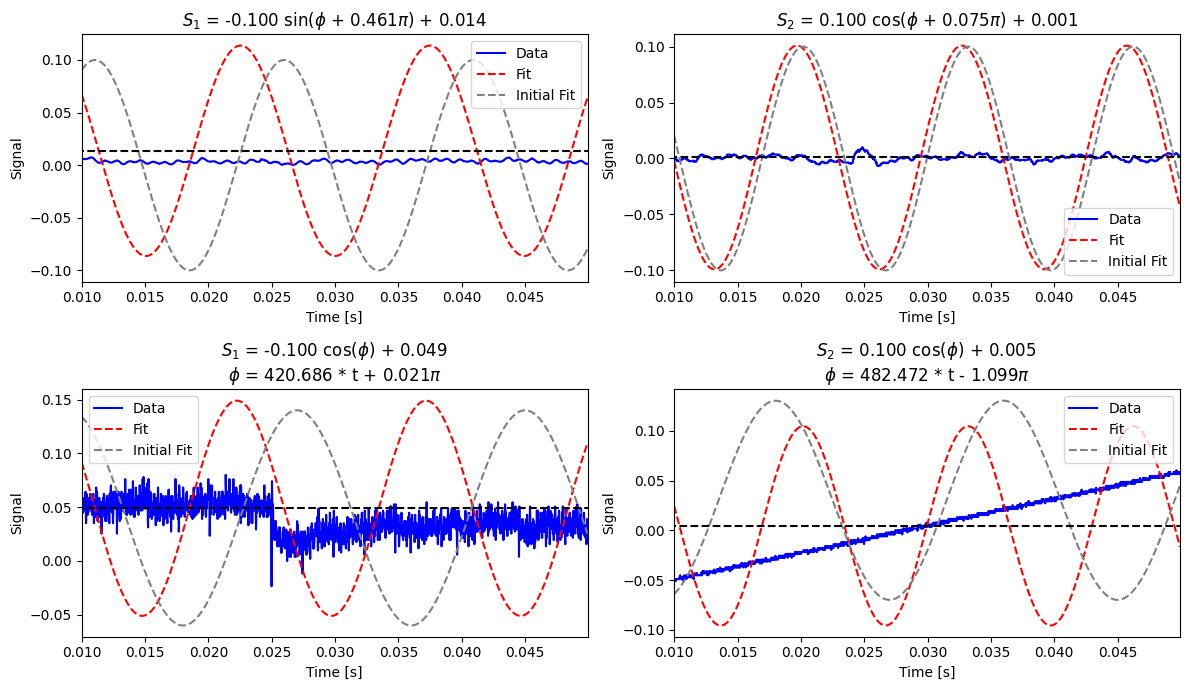

In [9]:
phi_setpoint = 0

obj.calibrate(do_plot=True)
plt.show()
plt.show()

## Rough tuning of the lock
The cell below can be used to roughly tune the phase setpoint to your desired value. Run the command in the cell below and observe the detector signals on the scope. A blue line is plotted as a guide to the eye on where the (green) IN1 signal should lock at ideally. Adjust the setpoint to change the lockpoint. $\textbf{The absolute value of the phase setpoint should not exceed 0.7 to maintain sufficient linearity in the error signal!}$ If higher setpoint are required, tune the `bandwidth` and `acbandwidth` parameters of the IQ modules and re-run the calibration!

Tune the setpoint of the `PID0` module untill the green signal is roughly aligned with the blue line. The fine-tuning of the mean and stability is done in the next step!

In [5]:
########################################
# Set the desired phase setpoint here! #
########################################
phase_setpoint = np.pi / 4

obj.start_locking(phase_setpoint)

## Fine-tuning the phase-lock
The cell below can be used to fine-tune the interferometer's intermittent phase-lock. After succesfully running the cell, it shows a statistical analysis of the measured detector voltages and the back-calculated corresponding phases and tomography fidelities. Each plot also features a line indicating the ideal value. Using the GUI, tune the `setpoint` parameter to change the mean of the statistical distributions in this measurement and tune the `p` and `i` parameters to reduce the statistical variation of the measurements untill you are satisfied with the achieved fidelity. It's recommended to use $\sim$ 100 shots at least for iterating the fine-tuning, when you come close to your final parameters, $\sim$ 1000 shots are recommended. It should also be noted that it might be tempting to increase the trigger repetition rate. Although I haven't done extensive testing on this, I have seen that that can influence the optimal parameters, especially when it comes to `i` and `p`. Make sure to use a repetition rate $\sim$ 10-50 Hz to avoid unnecessary complications that will not be present in the actual experiment.

This fidelity in the plot below is defined as follows. Assume you're trying to measure the following time-bin encoded photonic state:
$$ \ket{\psi} = \frac{1}{\sqrt{2}} \left(\ket{E} + \ket{L}\right).$$
Specifically, you're trying to measure that state in the basis
$$ \ket{M} = \frac{1}{\sqrt{2}} \left(\ket{E} + e^{i\phi}\ket{L} \right) $$
which is achieved by locking at a phase $\phi$ in the interferometer. Then, for a single incoming photon, the probability of measuring in the intermidiate time basis (as defined by the time it takes for the early photon to travel the long path and for the late photon to travel the short path) is given by
$$ P_\text{int} = |\braket{M|\psi}|^2 = \dots = \frac{1}{2} \left(1 + \cos(\phi) \right).$$
Now imagine that you have some error $\Delta \phi$ in the phase, then at that instance your probability of measuring the photon in this intermediate basis is given by
$$ P_\text{int} = \frac{1}{2} \left(1 + \cos(\phi+\Delta\phi) \right).$$
Conversly, imagine that you have a perfectly locked interferometer at some phase $\phi$, but instead your photonic state contains a phase error given by
$$ \ket{\tilde{\psi}} = \frac{1}{\sqrt{2}} \left(\ket{E} + e^{i \Delta \phi}\ket{L}\right).$$
If you now calculate the probability of measuring this photon in the perfect interferometer, this becomes:
$$ P_\text{int} = |\braket{M|\tilde{\psi}}|^2 = \dots = \frac{1}{2} \left(1 + \cos(\phi+\Delta\phi) \right).$$
Which is the same expression! All of this means that if you have a phase error $\Delta \phi$ in the interferometer, then there's no way of telling the difference between your interferometer being faulty, or your photonic state having decoherence up to some fidelity of:
$$ F = |\braket{\psi|\tilde{\psi}}|^2 = \frac{1}{2} \left(1 + \cos(\Delta \phi) \right)$$
This might not be the actual tomography fidelity bound, but it at least gives an indication on how to convert phase errors to fidelities and is therefore used as a guide in the statistical plot from the cell below.

100%|██████████| 100/100 [00:47<00:00,  2.12it/s]


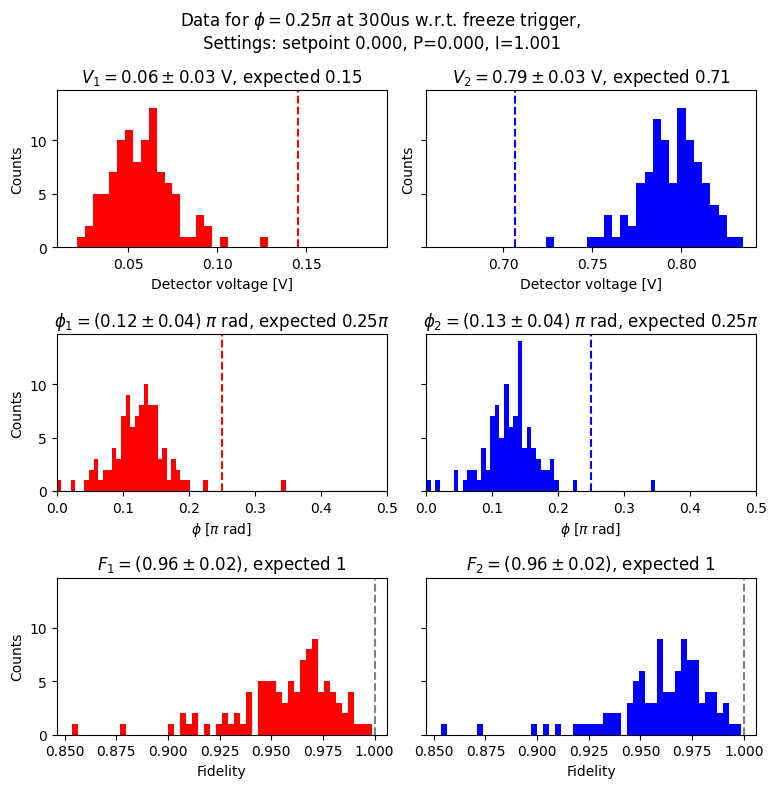

In [4]:
### SETTINGS ###
photon_timing = 300e-6
total_unlock_duration = 700e-6
num_shots = 100

ds = obj.test_intermittent_locking(
    phase_setpoint=phase_setpoint,
    num_shots=num_shots,
    photon_timing=photon_timing,
    total_unlock_duration=total_unlock_duration,
)

## Loading and plotting characterization data of the interferometer (as measured on 2025-07-14)
The cells below load and plot the characterization data that was measured for the interferometer on 2025-07-14. This data can be used as a reference, but should definitely not be seen as the best achievable results, as very little hard-core optimization was done to gather this data in a blind panic to gather it before the move...

In [5]:
detector_data_channel1 = np.zeros((9, 1000))
detector_data_channel2 = np.zeros((9, 1000))
phase_data_channel1 = np.zeros((9, 1000))
phase_data_channel2 = np.zeros((9, 1000))
fidelities_channel1 = np.zeros((9, 1000))
fidelities_channel2 = np.zeros((9, 1000))
phase_setpoints = np.zeros(9)

for i in range(9):
    phase_setpoint = i * np.pi / 4
    phase_setpoints[i] = phase_setpoint
    dataset = np.loadtxt(f"data/{i}-4/detector_data.csv", delimiter=',', skiprows=1)
    indices = dataset[:,0]
    ch1_photon_data = dataset[:,1]
    ch2_photon_data = dataset[:,2]
    function_increasing1 = phase_setpoint < np.pi
    function_increasing2 = phase_setpoint > np.pi
    phases_channel1 = obj.det_model_ch1.get_phase_from_voltage(ch1_photon_data, function_increasing=function_increasing1)
    phases_channel2 = obj.det_model_ch2.get_phase_from_voltage(ch2_photon_data, function_increasing=function_increasing2)
    detector_data_channel1[i, :] = ch1_photon_data
    detector_data_channel2[i, :] = ch2_photon_data
    phase_data_channel1[i, :] = phases_channel1
    phase_data_channel2[i, :] = phases_channel2
    fidelities_channel1[i, :] = 1/2 * (1 + np.cos(np.abs(phases_channel1 - phase_setpoint)))
    fidelities_channel2[i, :] = 1/2 * (1 + np.cos(np.abs(phases_channel2 - phase_setpoint)))

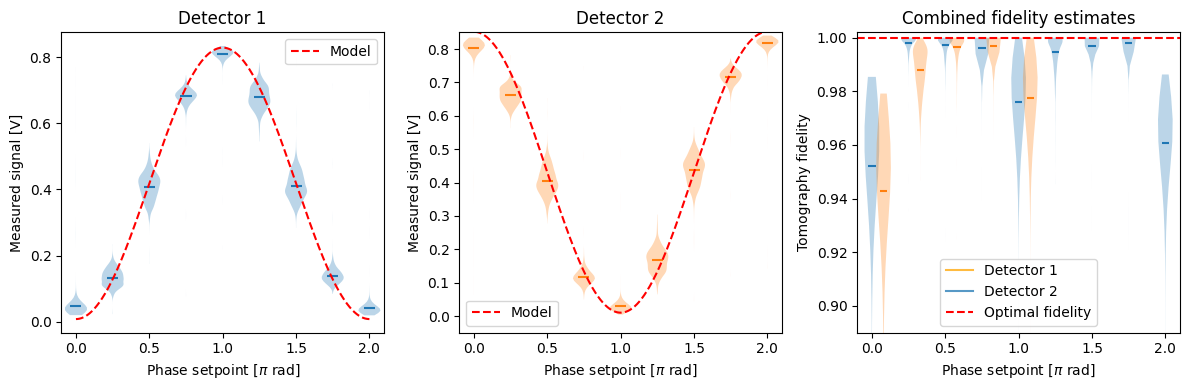

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].violinplot(detector_data_channel1.T, phase_setpoints/np.pi, showextrema=False, showmeans=True, widths=0.15)
ax[0].plot(np.linspace(0, 2*np.pi, 1000)/np.pi, obj.det_model_ch1.phase_relation(np.linspace(0, 2*np.pi, 1000)), color='red', label='Model', ls="--")
ax[0].set_xlabel(r"Phase setpoint [$\pi$ rad]")
ax[0].set_ylabel("Measured signal [V]")
ax[0].set_xlim(-0.1, 2.1)
ax[1].set_ylim(-0.05, 0.85)
ax[0].set_title("Detector 1")
ax[0].legend()

ax[1].plot(-1, -1, ls="--")
ax[1].violinplot(detector_data_channel2.T, phase_setpoints/np.pi, showextrema=False, showmeans=True, widths=0.15)
ax[1].plot(np.linspace(0, 2*np.pi, 1000)/np.pi, obj.det_model_ch2.phase_relation(np.linspace(0, 2*np.pi, 1000)), color='red', label='Model', ls="--")
ax[1].set_xlabel(r"Phase setpoint [$\pi$ rad]")
ax[1].set_xlim(-0.1, 2.1)
ax[1].set_ylim(-0.05, 0.85)
ax[1].set_title("Detector 2")
ax[1].set_ylabel("Measured signal [V]")
ax[1].legend()

ax[2].violinplot(fidelities_channel1.T, phase_setpoints/np.pi, showextrema=False, showmeans=True, widths=0.1)
ax[2].violinplot(fidelities_channel2.T, (phase_setpoints+0.25)/np.pi, showextrema=False, showmeans=True, widths=0.1)
ax[2].plot(-1, -1, color='orange', label="Detector 1", alpha=0.75)
ax[2].plot(-1, -1, color='tab:blue', label="Detector 2", alpha=0.75)
ax[2].set_xlabel(r"Phase setpoint [$\pi$ rad]")
ax[2].set_ylabel("Tomography fidelity")
ax[2].set_xlim(-0.1, 2.1)
ax[2].set_ylim(0.89, 1.002)
ax[2].axhline(1, color='red', linestyle='--', label='Optimal fidelity')
ax[2].legend(loc="lower center")
ax[2].set_title("Combined fidelity estimates")

fig.tight_layout()

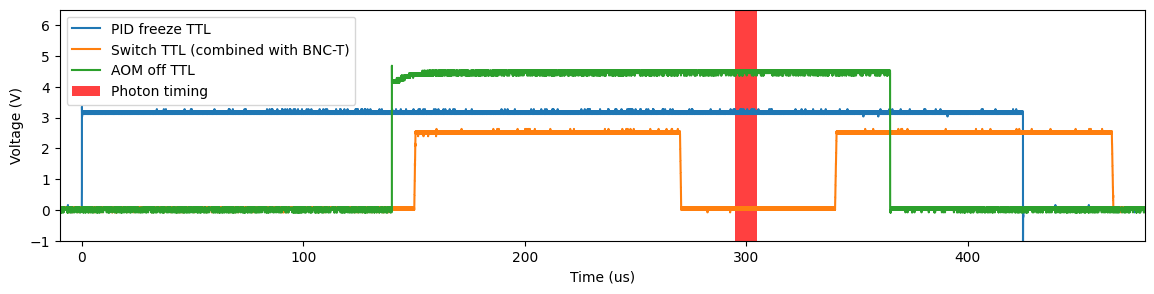

In [31]:
data = np.loadtxt("C:/Users/berni/Downloads/UMZI TTL Timings-0002.csv", delimiter=",", skiprows=3)

time = data[:, 0]
# eom_voltage = data[:, 1] * 1e-3 - 0.5
switches = data[:, 1]
aom = data[:, 2]
pid_pause = data[:, 3]

plt.figure(figsize=(14, 3))
plt.plot(time, pid_pause, label="PID freeze TTL")
plt.plot(time, switches, label="Switch TTL (combined with BNC-T)")
plt.plot(time, aom, label="AOM off TTL")
plt.xlabel("Time (us)")
plt.ylabel("Voltage (V)")
plt.xlim(-10, 480)
plt.ylim(-1, 6.5)
plt.fill_betweenx([-10, 10], 295, 305, color="r", alpha=0.75, edgecolor=None, label="Photon timing")
plt.legend(loc="upper left")
plt.show()